In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('dark_background')

,height
0,66.841635
1,64.657852
2,64.012084
3,64.156301
4,63.609508
...,...
4995,61.485234
4996,64.307613
4997,62.300935
4998,63.299496


Sample mean: 65.00918399911708
Sample std:  3.0097648783988045

Lower bound: None
Upper bound: 70
True probability:   0.9522
Sample probability: 0.9508


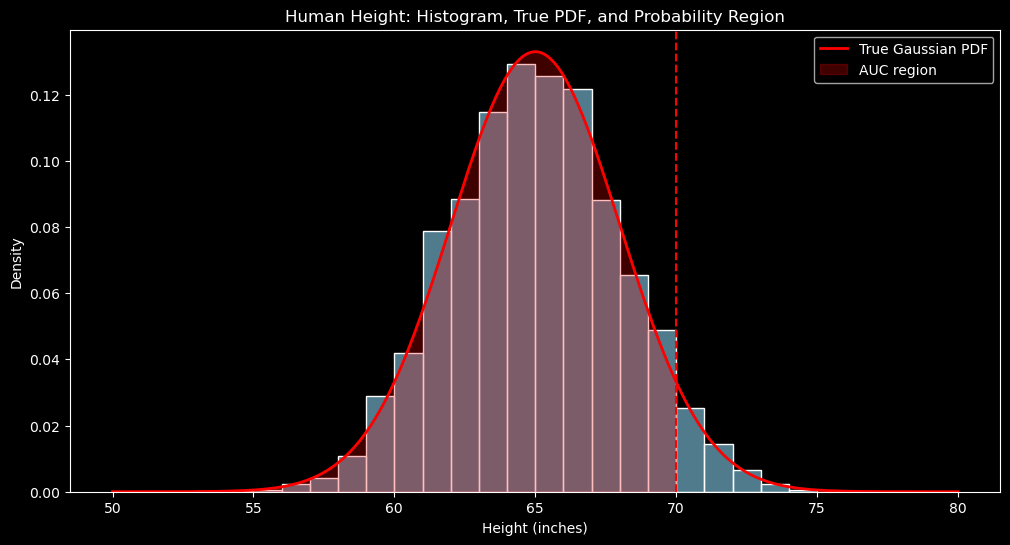

In [7]:
# ======================================================
# PARAMETERS — realistic human height model (in inches)
# ======================================================
mu = 65      # average adult height ≈ 5'5"
sigma = 3    # typical std for adult heights

num_samples = 5000
bin_width = 1
bins = np.arange(50, 80 + bin_width, bin_width)

lower = None   # or None
upper = 70   # or None

# ======================================================
# SAMPLE FROM A CONTINUOUS GAUSSIAN DISTRIBUTION
# ======================================================
samples = np.random.normal(mu, sigma, size=num_samples)

df = pd.DataFrame({
    "height": samples,
})
display(df)

# ======================================================
# PRINT SAMPLE MEAN AND STD
# ======================================================
print("Sample mean:", np.mean(samples))
print("Sample std: ", np.std(samples, ddof=1))

# ======================================================
# BUILD HISTOGRAM (EMPIRICAL DISTRIBUTION)
# ======================================================
plt.figure(figsize=(12,6))

sns.histplot(
    samples,
    bins=bins,
    stat="density",
    color="skyblue",
    alpha=0.6,
    edgecolor='white'
)

# ======================================================
# PLOT THE TRUE GAUSSIAN DENSITY (PDF)
# ======================================================
xs = np.linspace(bins[0], bins[-1], 400)
pdf = norm.pdf(xs, mu, sigma)

pdf_color = 'r'   # <-- unify all related elements to this color

plt.plot(xs, pdf, pdf_color, linewidth=2, label="True Gaussian PDF")

# ======================================================
# INTERVAL PROBABILITY QUERY
# ======================================================

# True probability
if lower is None and upper is None:
    true_prob = 1.0
elif lower is None:
    true_prob = norm.cdf(upper, mu, sigma)
elif upper is None:
    true_prob = 1 - norm.cdf(lower, mu, sigma)
else:
    true_prob = norm.cdf(upper, mu, sigma) - norm.cdf(lower, mu, sigma)

# Sample probability
if lower is None and upper is None:
    sample_prob = 1.0
elif lower is None:
    sample_prob = np.mean(samples < upper)
elif upper is None:
    sample_prob = np.mean(samples > lower)
else:
    sample_prob = np.mean((samples >= lower) & (samples <= upper))

print()
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")
print(f"True probability:   {true_prob:.4f}")
print(f"Sample probability: {sample_prob:.4f}")

# ======================================================
# VISUALIZE INTERVAL REGION ON THE PDF
# ======================================================
# vertical lines (match PDF color)
if lower is not None:
    plt.axvline(lower, color=pdf_color, linestyle="--", linewidth=1.5)
if upper is not None:
    plt.axvline(upper, color=pdf_color, linestyle="--", linewidth=1.5)

# Fill AUC region (match PDF color)
if lower is None:
    fill_start = xs.min()
else:
    fill_start = lower

if upper is None:
    fill_end = xs.max()
else:
    fill_end = upper

mask = (xs >= fill_start) & (xs <= fill_end)
plt.fill_between(xs[mask], pdf[mask], color=pdf_color, alpha=0.25, label="AUC region")

# ======================================================
# LABELS / TITLE
# ======================================================
plt.title("Human Height: Histogram, True PDF, and Probability Region")
plt.xlabel("Height (inches)")
plt.ylabel("Density")
plt.legend()

plt.show()